In [2]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

<H1>Przygotowanie zbioru danych: XOR<H1>

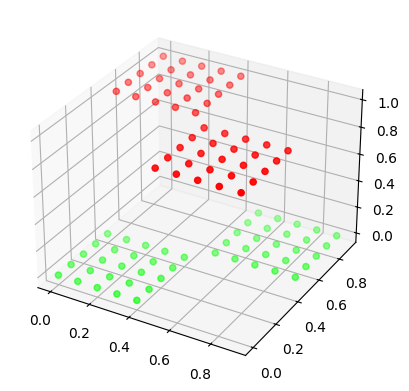

In [3]:
x = np.arange(0, 1, 0.1)
x,y = np.meshgrid(x, x)

dataX = x.flatten()
dataY = y.flatten()
dataXY1 = np.column_stack((dataX,dataY,np.ones(len(dataX))))
dataXY = np.column_stack((dataX,dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rgb = [[1,0,0] if cc else [0,1,0] for cc in data_labels]

ax.scatter(dataX, dataY, data_labels, c=rgb)

plt.show()

<H1>Utworzenie funkcji przynależności</H1>

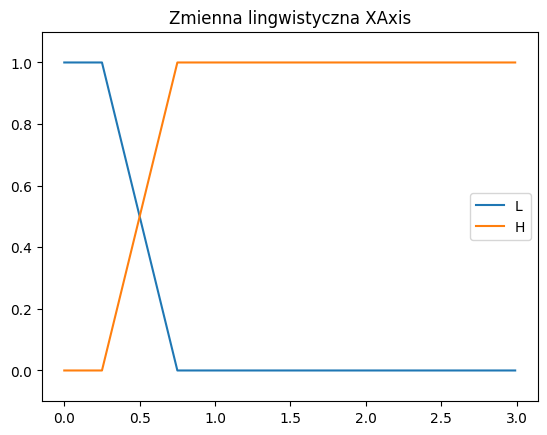

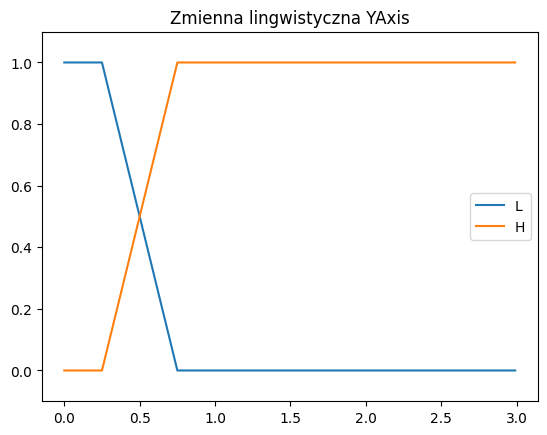

In [4]:
varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) # low, high
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

#mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
#varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
#varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

<H1>Inicjalizacja systemu ANFIS</H1>

Parametry początkowe:
Przesłanki:  [[0.5, 0.5], [0.5, 0.5]] 
Konkluzje:  [[0.64343346 0.88160333 0.21887862]
 [0.06440084 0.96137584 0.65913063]
 [0.42804724 0.84551199 0.06588339]
 [0.3161386  0.36727424 0.71317874]]


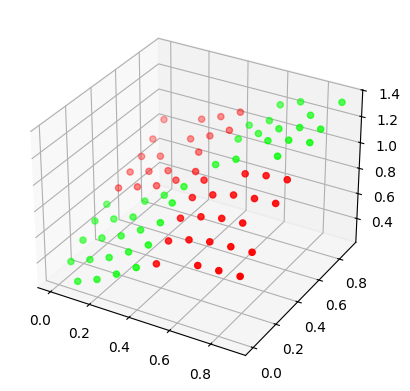

In [5]:
X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

fis = ANFIS([varX, varY], X_train.T, y_train)

print("Parametry początkowe:\nPrzesłanki: ",fis.premises, "\nKonkluzje: ", fis.tsk)

fis.show_results()

<H1>Uczenie systemu ANFIS</H1>

Optymalizacja zakończona!
z blędem:   1.0411984310872317e-06
Liczba ew:  36500
Liczba it:  50
TIME elapsed:  2.7893364429473877


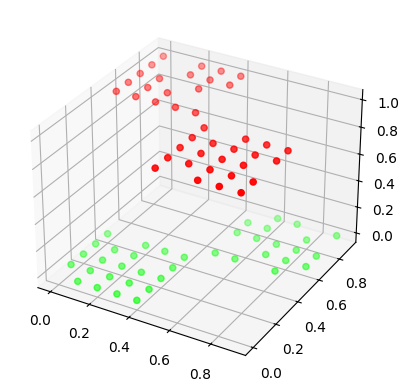

In [6]:
start = time.time()
fis.train(True, True, False, True, n_iter=50)
end = time.time()
print("TIME elapsed: ", end - start)   
fis.training_data = X_train.T
fis.expected_labels = y_train
fis.show_results()

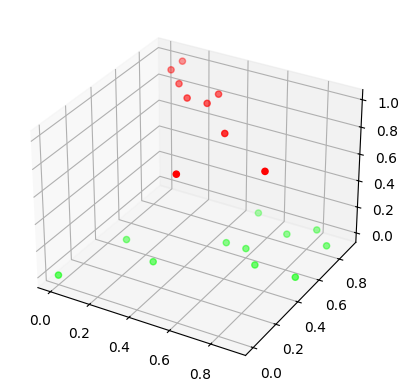

[[11  0]
 [ 0  9]]


In [7]:
fis.training_data = X_test.T
fis.expected_labels = y_test
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))

<H1>Sprawdzanie parametrów jakich nauczył się system</H1>

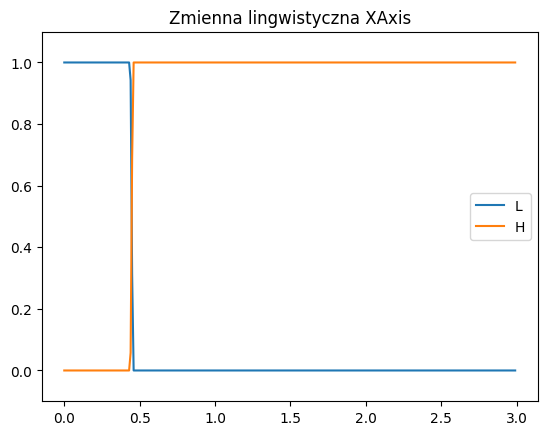

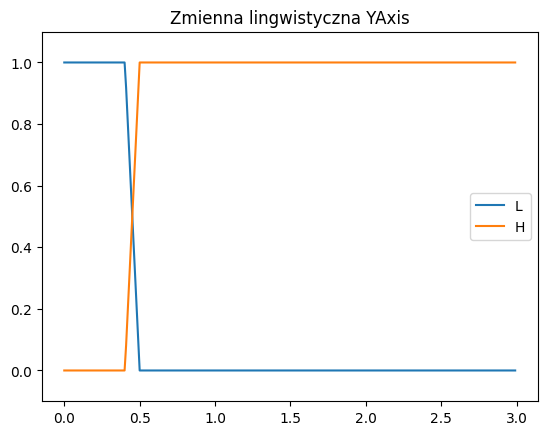

In [8]:
#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

In [9]:
print("Parametry końcowe:\nPrzesłanki: ", repr(fis.premises), "\nKonkluzje: ", repr(fis.tsk))

Parametry końcowe:
Przesłanki:  array([[0.4470059 , 0.01583592],
       [0.45087851, 0.09760369]]) 
Konkluzje:  array([[0.00000000e+00, 4.94973535e-10, 3.78059628e-13],
       [1.45494785e-11, 1.23710835e-07, 9.99999971e-01],
       [4.43850586e-12, 0.00000000e+00, 9.99999963e-01],
       [1.49327771e-11, 1.13798730e-11, 2.62868367e-11]])


#### Zapisanie nauczonych parametrów do zmiennych

In [10]:
learned_premises = fis.premises.copy()
learned_tsk = fis.tsk.copy()

<H1>Sprawdzanie wpływu parametrów na wyniki systemu</H1>

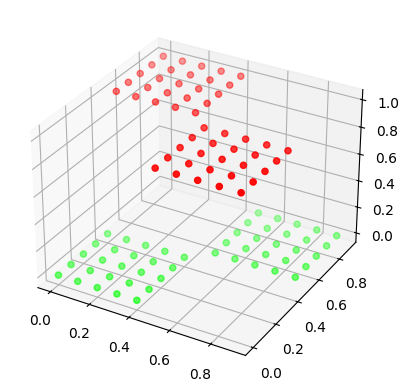

In [11]:
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

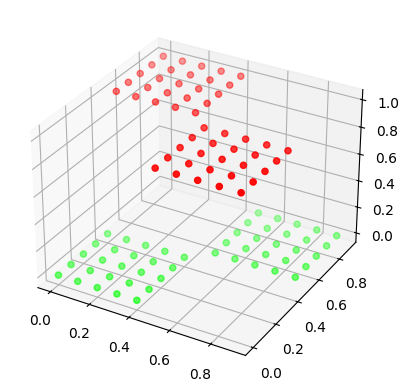

In [12]:
fis.premises = learned_premises
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

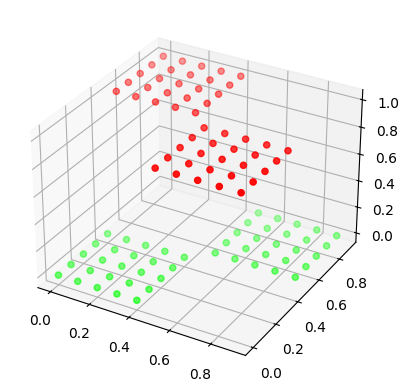

In [13]:
fis.tsk = learned_tsk
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

<H1>Zadanie</H1>

Naucz system ANFIS tabliczki mnożenia. Zacznij od rozmiaru 2x2 i zwiększaj w obu kierunkach z krokiem 1 (kolejno 2x2, 3x3, 4x4, 5x5). Mierz czas jaki jest potrzebny na nauczenie systemu w zależności od wymiarów tabliczki. Zrób wykres wymiaru tabliczki od czasu uczenia i wyślij wraz ze swoim komentarzem na maila iperenc@kis.p.lodz.pl. Nie musisz dojść do rozmiaru 10x10, wystarczy 5x5, ważne żeby było widać jaka jest zależność.

Tabliczka: 2x2


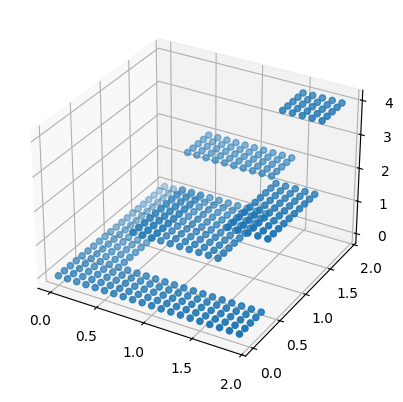

Optymalizacja zakończona!
z blędem:   5.456280897747433
Liczba ew:  150027
Liczba it:  120


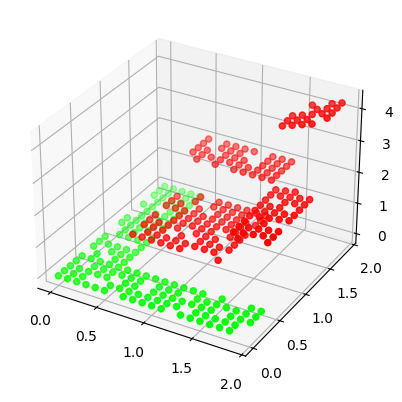

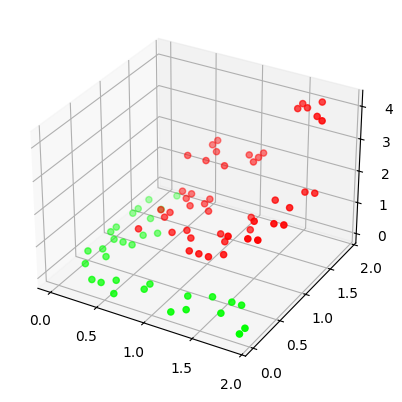

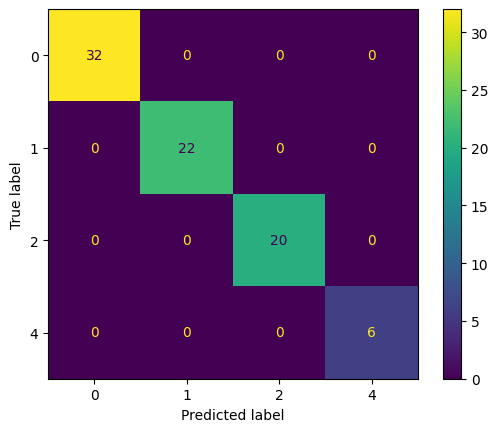

Tabliczka: 3x3


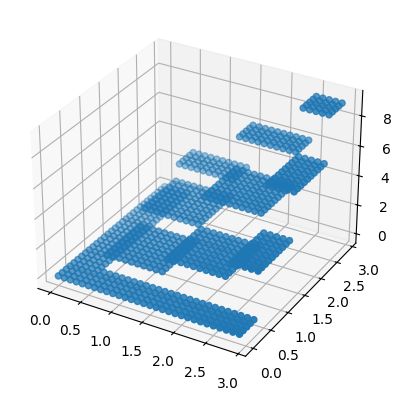

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   37.51773861284897
Liczba ew:  1038023
Liczba it:  270


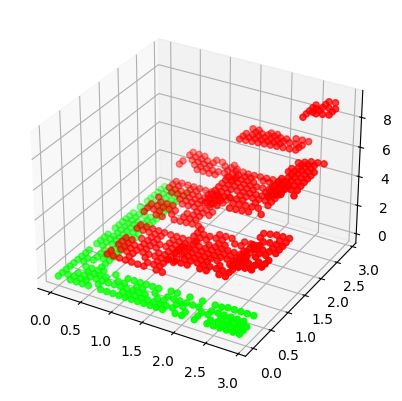

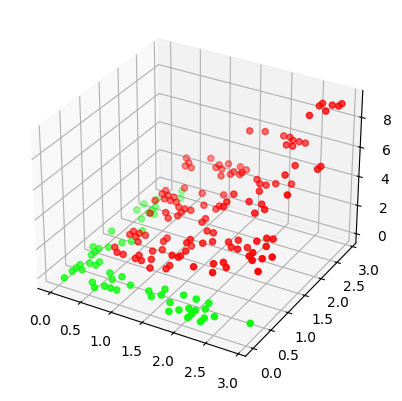

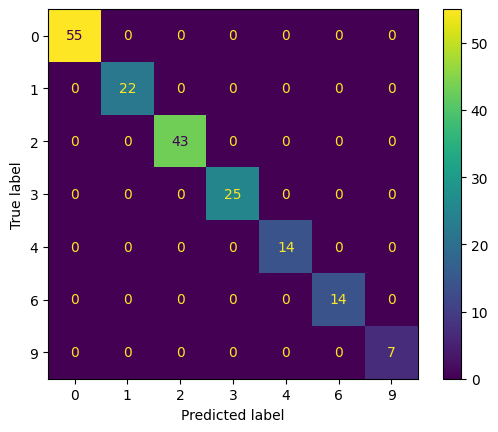

Tabliczka: 4x4


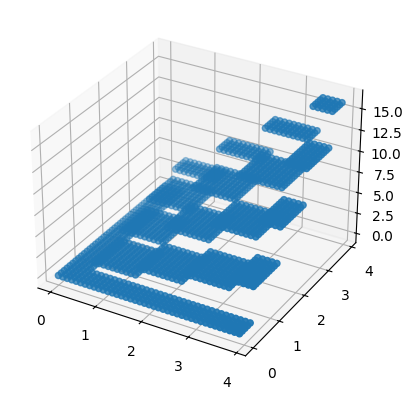

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


Optymalizacja zakończona!
z blędem:   243.52843721273834
Liczba ew:  2453743
Liczba it:  480


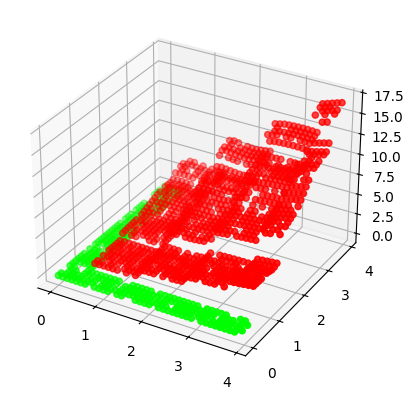

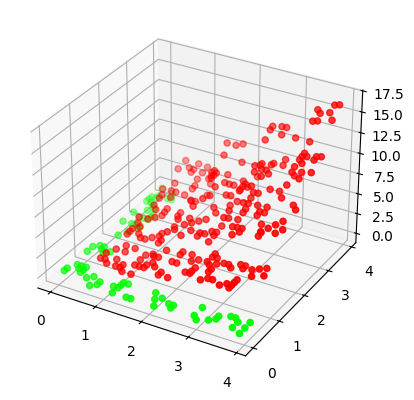

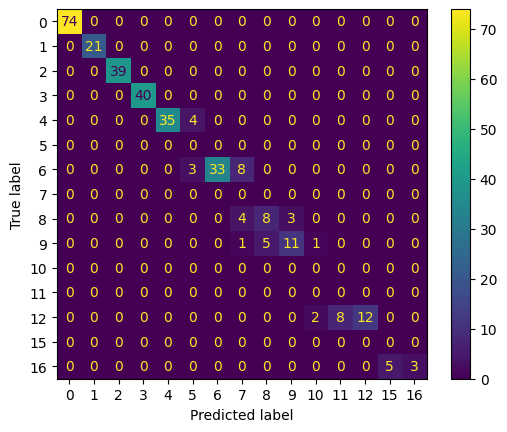

Tabliczka: 5x5


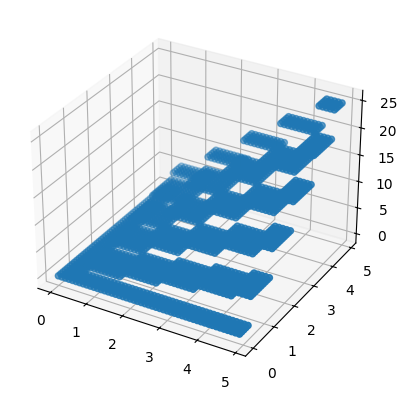

c:\Users\Filip\Documents\mgr-siium\metody_sztucznej_itenligencji\ANFIS.py:89: RuntimeWarning: invalid value encountered in divide
  Rnorm = R / Rsum


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import accuracy_score

sizes = [2, 3, 4, 5]
times = []
accuracies = []

mf1 = [
        [-0.25, 0.125, 0.125, 0.25], 
        [0.25, 0.125, 0.1, 0.1], 
        [0.5, 0.25, 0.1, 0.1], 
        [0.75, 0.25, 0.125, 1.25],
        [1.25, 0.75, -0.25, 1.25]
    ]
    
labels = ["L","H", "M", "S", "XL"]

def custom_round(val):
    return int(val + 0.5)

for size in sizes:
    print(f"Tabliczka: {size}x{size}")

    x = np.arange(0, size, 0.1)
    x,y = np.meshgrid(x, x)

    dataX = x.flatten()
    dataY = y.flatten()
    dataXY = np.column_stack((dataX,dataY))   

    data_labels = [custom_round(a) * custom_round(b) for a, b in dataXY]

    # for x in range(len(dataXY)):
    #     print(x, dataXY[x], data_labels[x])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dataX, dataY, data_labels)
    plt.show()

    # varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) 
    # varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

    varX = FuzzyInputVariable_List_Trapezoids(mf1[:size], "XAxis", labels[:size])
    varY = FuzzyInputVariable_List_Trapezoids(mf1[:size], "YAxis", labels[:size])

    X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

    fis = ANFIS([varX, varY], X_train.T, y_train)

    start = time.time()
    fis.train(True, True, False, True, n_iter=30*size*size)
    end = time.time()
    times.append(end-start)
    fis.training_data = X_train.T
    fis.expected_labels = y_train
    fis.show_results()

    fis.training_data = X_test.T
    fis.expected_labels = y_test
    fis.show_results()

    y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
    y_pred = list(map(round,y_pred.flatten()))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(sizes, times, marker='o')
axs[0].set_xlabel('Rozmiar tabliczki (NxN)')
axs[0].set_ylabel('Czas uczenia [s]')
axs[0].set_title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
axs[0].grid(True)

axs[1].plot(sizes, accuracies, marker='o', color='green')
axs[1].set_xlabel('Rozmiar tabliczki (NxN)')
axs[1].set_ylabel('Dokładność')
axs[1].set_title('Dokładność ANFIS vs rozmiar tabliczki mnożenia')
axs[1].grid(True)

plt.tight_layout()
plt.show()
